# Proyecto Final — Ecuaciones Diferenciales Ordinarias
## Avance 2 (Parcial 3): Simulación numérica del Oscilador Armónico Amortiguado

**Universidad Interamericana de Panamá** — Facultad de Ingeniería, Arquitectura y Diseño
**Asignatura:** Ecuaciones Diferenciales Ordinarias
**Modelo asignado:** Oscilador Amortiguado
**Modalidad:** Equipo de 5 estudiantes

Este notebook implementa la simulación numérica del modelo desarrollado analíticamente en el
**Avance 1**, donde se dedujo la ecuación

$$m\,x'' + c\,x' + k\,x = 0 \qquad\Longleftrightarrow\qquad x'' + 2\beta x' + \omega_0^2 x = 0$$

con $\omega_0=\sqrt{k/m}$ (frecuencia natural) y $\beta = c/(2m)$ (coeficiente de amortiguamiento).

**Contenido de este avance:**
1. Implementación numérica (Runge–Kutta de 4.º orden, manual)
2. Validación de la implementación contra `scipy.integrate.solve_ivp`
3. Cuatro escenarios de simulación (los tres regímenes de amortiguamiento + una variación de condiciones iniciales)
4. Gráficos comparativos superpuestos
5. Discusión preliminar de resultados


## Reproducibilidad

Esta simulación es **totalmente determinista**: no se utiliza ningún generador de números
aleatorios, por lo que ejecutar este notebook de principio a fin produce siempre los mismos
resultados numéricos y gráficos. Los paquetes utilizados y sus versiones se listan en
`requirements.txt` (ver README del repositorio) para garantizar que cualquier persona pueda
reproducir el entorno exacto de ejecución.


## 1. Parámetros base del sistema

Se utiliza un sistema masa–resorte–amortiguador ilustrativo con $m = 1\ \text{kg}$ y
$k = 25\ \text{N/m}$, de modo que $\omega_0 = \sqrt{k/m} = 5\ \text{rad/s}$. A partir de
$\omega_0$ se calcula, para cada escenario, el coeficiente de amortiguamiento $c$ necesario
para ubicar al sistema en el régimen deseado, recordando que $\beta = \omega_0$ marca el
amortiguamiento crítico (ver Avance 1, apartado 3.3).


In [8]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parámetros físicos base (sistema ilustrativo)
m = 1.0        # masa [kg]
k = 25.0       # constante del resorte [N/m]
omega0 = np.sqrt(k / m)   # frecuencia angular natural [rad/s]

print(f"omega0 = {omega0} rad/s  (frecuencia natural sin amortiguamiento)")
print(f"Amortiguamiento crítico: c_crit = 2*sqrt(k*m) = {2*np.sqrt(k*m)} N·s/m")

omega0 = 5.0 rad/s  (frecuencia natural sin amortiguamiento)
Amortiguamiento crítico: c_crit = 2*sqrt(k*m) = 10.0 N·s/m


## 2. Modelo en forma de sistema de primer orden

Para resolver numéricamente la EDO de segundo orden se reescribe como un sistema de dos
ecuaciones de primer orden, definiendo $y_1 = x$ (posición) y $y_2 = x'$ (velocidad):

$$\frac{dy_1}{dt} = y_2 \qquad\qquad \frac{dy_2}{dt} = -2\beta\, y_2 - \omega_0^2\, y_1$$

Esta es la forma estándar $\mathbf{y}' = f(t, \mathbf{y})$ que requieren los métodos
numéricos de un paso (Euler, Runge–Kutta, etc.).


In [9]:
def rhs(t, y, beta, omega0):
    """
    Lado derecho del sistema de primer orden equivalente al oscilador amortiguado.
    y[0] = x (posición), y[1] = v = x' (velocidad)
    Devuelve [dx/dt, dv/dt].
    """
    x, v = y
    dxdt = v
    dvdt = -2*beta*v - omega0**2 * x
    return np.array([dxdt, dvdt])

## 3. Método numérico: Runge–Kutta de 4.º orden (RK4)

Se eligió **RK4** en lugar del método de Euler porque, para sistemas oscilatorios, Euler
explícito introduce un crecimiento artificial de energía (inestabilidad numérica) salvo que
se use un paso de tiempo extremadamente pequeño: al evaluar la pendiente solo al inicio de
cada paso, sistemáticamente "empuja" la trayectoria hacia afuera de la espiral de decaimiento
real. RK4 evalúa la pendiente en cuatro puntos dentro de cada paso (inicio, dos puntos
intermedios y final) y los combina con pesos $1/6, 2/6, 2/6, 1/6$, lo que reduce el error de
truncamiento local de orden $O(h^2)$ (Euler) a $O(h^4)$ sin requerir herramientas de análisis
numérico más allá de las vistas en un curso introductorio de EDO. Es, además, el método que
usan internamente casi todos los solvers estándar (incluido `solve_ivp`), por lo que es una
elección apropiada y ampliamente reconocida para este nivel.


In [10]:
def rk4(f, t0, y0, t_end, h, args=()):
    """
    Integrador Runge-Kutta de 4.º orden, paso fijo h.

    f      : función f(t, y, *args) -> dy/dt
    t0     : tiempo inicial
    y0     : condición inicial [x0, v0]
    t_end  : tiempo final
    h      : tamaño de paso
    args   : parámetros adicionales de f (beta, omega0)

    Devuelve: t (arreglo de tiempos), y (arreglo Nx2 con posición y velocidad)
    """
    n = int(round((t_end - t0) / h))
    t = np.linspace(t0, t_end, n + 1)
    y = np.zeros((n + 1, len(y0)))
    y[0] = y0

    for i in range(n):
        ti, yi = t[i], y[i]
        k1 = f(ti,         yi,             *args)
        k2 = f(ti + h/2,   yi + h/2 * k1,  *args)
        k3 = f(ti + h/2,   yi + h/2 * k2,  *args)
        k4 = f(ti + h,     yi + h   * k3,  *args)
        y[i + 1] = yi + (h / 6) * (k1 + 2*k2 + 2*k3 + k4)

    return t, y

## 4. Validación de la implementación

Antes de usar el integrador RK4 propio en los escenarios de interés, se valida comparando su
resultado contra `scipy.integrate.solve_ivp` (método RK45 adaptativo de alta precisión) para
el caso subamortiguado. Si la diferencia máxima entre ambas soluciones es del orden de
$10^{-6}$ o menor, se considera que la implementación manual es correcta.


Diferencia máxima RK4 (manual) vs solve_ivp: 9.66e-08
Validación exitosa: la implementación de RK4 es correcta.


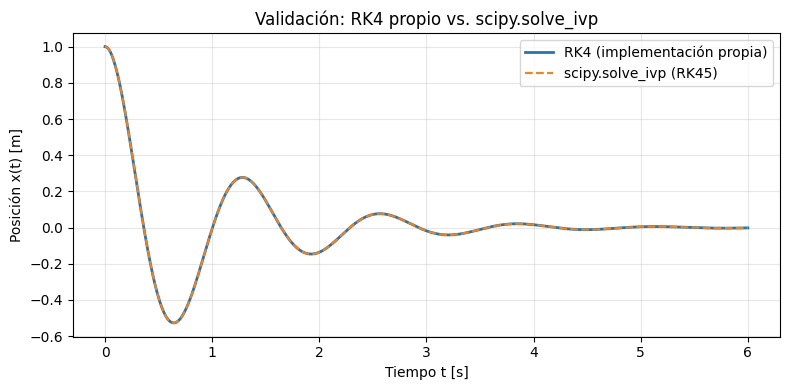

In [11]:
# Caso de prueba: régimen subamortiguado, x0=1, v0=0
beta_test = 1.0
x0_test, v0_test = 1.0, 0.0
h = 0.01

t_rk4, y_rk4 = rk4(rhs, 0, [x0_test, v0_test], 6, h, args=(beta_test, omega0))

sol_ref = solve_ivp(rhs, [0, 6], [x0_test, v0_test], args=(beta_test, omega0),
                     t_eval=t_rk4, method='RK45', rtol=1e-10, atol=1e-12)

diff_max = np.max(np.abs(y_rk4[:, 0] - sol_ref.y[0]))
print(f"Diferencia máxima RK4 (manual) vs solve_ivp: {diff_max:.2e}")
assert diff_max < 1e-5, "La implementación RK4 no coincide con la referencia"
print("Validación exitosa: la implementación de RK4 es correcta.")

plt.figure(figsize=(8, 4))
plt.plot(t_rk4, y_rk4[:, 0], label='RK4 (implementación propia)', linewidth=2)
plt.plot(t_rk4, sol_ref.y[0], '--', label='scipy.solve_ivp (RK45)', linewidth=1.5)
plt.xlabel('Tiempo t [s]'); plt.ylabel('Posición x(t) [m]')
plt.title('Validación: RK4 propio vs. scipy.solve_ivp')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('validacion_rk4.png', dpi=150)
plt.show()

## 5. Definición de los escenarios

Se simulan **cuatro escenarios**: los tres regímenes de amortiguamiento con condiciones
iniciales fijas ($x_0=1\ \text{m}$, $v_0=0\ \text{m/s}$, un desplazamiento inicial sin
velocidad, como al soltar el resorte estirado), y un cuarto escenario que mantiene el régimen
subamortiguado pero cambia las condiciones iniciales a un **impulso de velocidad** puro
($x_0=0$, $v_0=5\ \text{m/s}$), para aislar el efecto de las condiciones iniciales frente al
efecto del amortiguamiento.

| Escenario | c [N·s/m] | β [1/s] | Régimen | x₀ [m] | v₀ [m/s] |
|---|---|---|---|---|---|
| A | 2  | 1  | Subamortiguado (β<ω₀)     | 1 | 0 |
| B | 10 | 5  | Crítico (β=ω₀)            | 1 | 0 |
| C | 20 | 10 | Sobreamortiguado (β>ω₀)   | 1 | 0 |
| D | 2  | 1  | Subamortiguado, otra C.I. | 0 | 5 |


In [12]:
escenarios = {
    'A: Subamortiguado':            dict(c=2.0,  x0=1.0, v0=0.0, color='tab:blue'),
    'B: Crítico':                   dict(c=10.0, x0=1.0, v0=0.0, color='tab:green'),
    'C: Sobreamortiguado':          dict(c=20.0, x0=1.0, v0=0.0, color='tab:red'),
    'D: Subamortiguado (otra C.I.)':dict(c=2.0,  x0=0.0, v0=5.0, color='tab:purple'),
}

t_end, h = 6.0, 0.005
resultados = {}

for nombre, p in escenarios.items():
    beta = p['c'] / (2 * m)
    t, y = rk4(rhs, 0, [p['x0'], p['v0']], t_end, h, args=(beta, omega0))
    resultados[nombre] = dict(t=t, x=y[:, 0], v=y[:, 1], beta=beta, **p)
    print(f"{nombre:32s} beta={beta:5.2f}  omega0={omega0:.2f}  "
          f"régimen={'sub' if beta<omega0 else ('crítico' if beta==omega0 else 'sobre')}")

A: Subamortiguado                beta= 1.00  omega0=5.00  régimen=sub
B: Crítico                       beta= 5.00  omega0=5.00  régimen=crítico
C: Sobreamortiguado              beta=10.00  omega0=5.00  régimen=sobre
D: Subamortiguado (otra C.I.)    beta= 1.00  omega0=5.00  régimen=sub


## 6. Gráfico comparativo: los tres regímenes de amortiguamiento

Mismo desplazamiento inicial (x₀ = 1 m, v₀ = 0) para los tres escenarios A, B y C, superpuestos
en una sola figura.


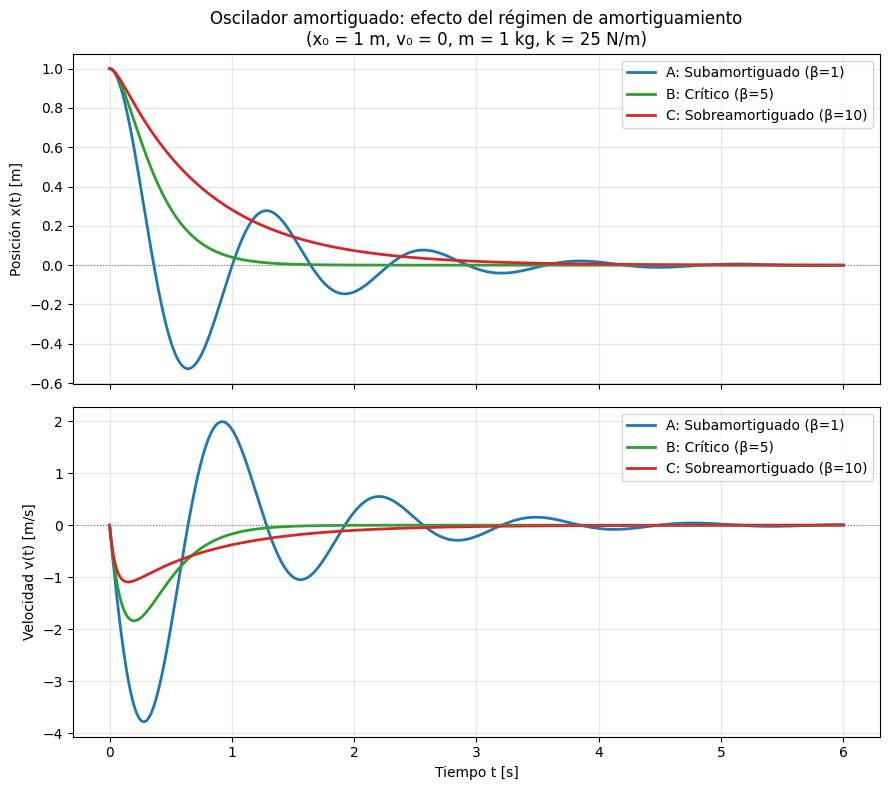

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

for nombre in ['A: Subamortiguado', 'B: Crítico', 'C: Sobreamortiguado']:
    r = resultados[nombre]
    etiqueta = f"{nombre} (β={r['beta']:.0f})"
    ax1.plot(r['t'], r['x'], label=etiqueta, color=r['color'], linewidth=2)
    ax2.plot(r['t'], r['v'], label=etiqueta, color=r['color'], linewidth=2)

ax1.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax1.set_ylabel('Posición x(t) [m]')
ax1.set_title('Oscilador amortiguado: efecto del régimen de amortiguamiento\n'
              '(x₀ = 1 m, v₀ = 0, m = 1 kg, k = 25 N/m)')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax2.set_xlabel('Tiempo t [s]'); ax2.set_ylabel('Velocidad v(t) [m/s]')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('regimenes_amortiguamiento.png', dpi=150)
plt.show()

**Observaciones preliminares (régimen):**

- El escenario **A (subamortiguado)** es el único que oscila: cruza el eje x = 0 varias veces
  mientras su amplitud decae siguiendo la envolvente $e^{-\beta t}$, tal como predice la
  solución analítica del Avance 1 (apartado 3.4).
- El escenario **B (crítico)** regresa al equilibrio sin oscilar y, de los tres, es el que lo
  hace en **menor tiempo** sin cruzar el eje — la propiedad que lo hace atractivo en el diseño
  de amortiguadores de puertas y suspensiones (Avance 1, apartado 3.5).
- El escenario **C (sobreamortiguado)** también regresa sin oscilar, pero de forma
  notablemente más lenta que el caso crítico, confirmando que un exceso de amortiguamiento no
  es "más seguro": simplemente ralentiza el retorno al equilibrio (Avance 1, apartado 3.6).
- Los tres casos parten del mismo punto (x₀=1) con la misma pendiente inicial (v₀=0); toda la
  diferencia en la dinámica proviene exclusivamente de la relación entre β y ω₀, confirmando la
  reflexión de sensibilidad hecha en el Avance 1 (apartado 3.7).
- El panel de **velocidad** hace más evidente la diferencia cualitativa entre regímenes: en A
  (subamortiguado), v(t) oscila y cruza el cero repetidamente —cada cruce coincide con un
  máximo o mínimo de x(t)—, mientras que en B y C la velocidad regresa a cero **una sola vez**,
  sin cambiar de signo, reflejando que el cuerpo nunca invierte su dirección de movimiento.


## 7. Gráfico comparativo: efecto de las condiciones iniciales

Se compara el escenario A (subamortiguado, x₀=1, v₀=0) contra el escenario D (mismo β, pero
x₀=0, v₀=5), para aislar el efecto de las condiciones iniciales del efecto del amortiguamiento.


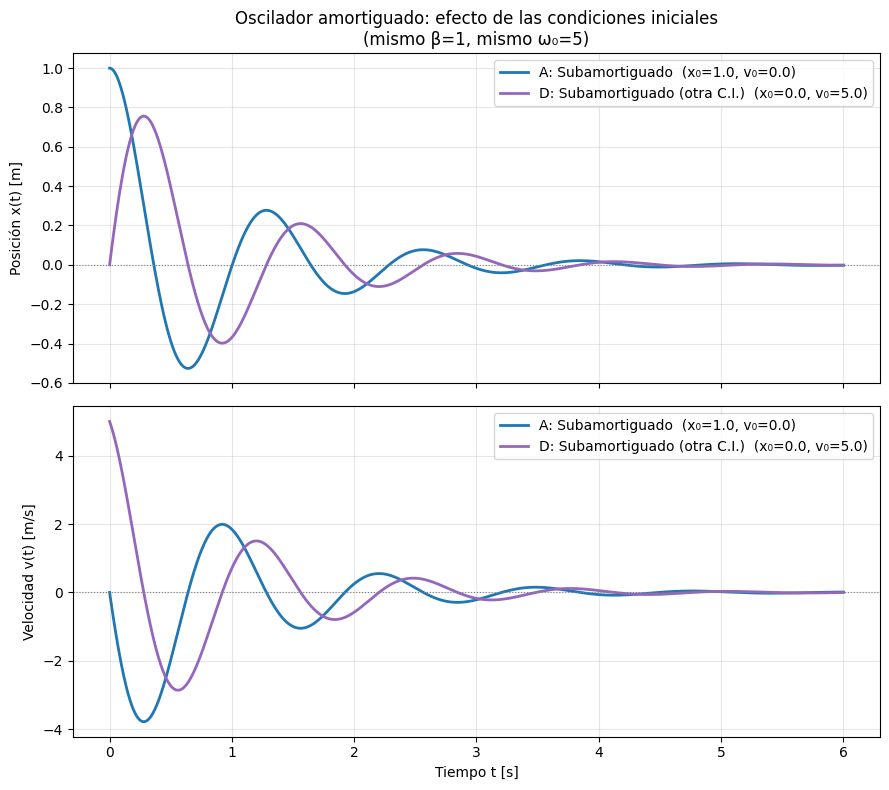

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

for nombre in ['A: Subamortiguado', 'D: Subamortiguado (otra C.I.)']:
    r = resultados[nombre]
    etiqueta = f"{nombre}  (x₀={r['x0']}, v₀={r['v0']})"
    ax1.plot(r['t'], r['x'], label=etiqueta, color=r['color'], linewidth=2)
    ax2.plot(r['t'], r['v'], label=etiqueta, color=r['color'], linewidth=2)

ax1.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax1.set_ylabel('Posición x(t) [m]')
ax1.set_title('Oscilador amortiguado: efecto de las condiciones iniciales\n(mismo β=1, mismo ω₀=5)')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax2.set_xlabel('Tiempo t [s]'); ax2.set_ylabel('Velocidad v(t) [m/s]')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('condiciones_iniciales.png', dpi=150)
plt.show()

**Observaciones preliminares (condiciones iniciales):**

- Ambos escenarios comparten el mismo régimen (subamortiguado, β=1 < ω₀=5) y por lo tanto la
  **misma frecuencia amortiguada** $\omega_d=\sqrt{\omega_0^2-\beta^2}$ y la **misma
  envolvente de decaimiento** $e^{-\beta t}$: ambas curvas se extinguen al mismo ritmo.
- Lo que cambia es la **fase y la amplitud aparente** del movimiento: el escenario D, al partir
  con velocidad inicial en lugar de desplazamiento inicial, alcanza su primer máximo de
  desplazamiento *después* de t=0, mientras que A comienza exactamente en su máximo.
- Esto confirma, de forma numérica, lo señalado analíticamente en el Avance 1: las condiciones
  iniciales determinan las constantes $C_1$ y $C_2$ (equivalentemente, la amplitud y fase de la
  solución), pero **no alteran el régimen de amortiguamiento**, que depende únicamente de la
  relación entre β y ω₀.
- En el panel de velocidad se ve el mismo desfase: el escenario A arranca con v(0)=0 (parte del
  reposo, en su punto de máximo desplazamiento), mientras que D arranca con v(0)=5 m/s en x=0;
  ambas curvas de velocidad terminan oscilando con la misma envolvente $e^{-\beta t}$, solo
  desplazadas en el tiempo.


## 8. Discusión preliminar general

Los cuatro escenarios simulados numéricamente reproducen con exactitud el comportamiento
cualitativo predicho por la solución analítica derivada en el Avance 1: el parámetro β/ω₀
gobierna si el sistema oscila o no y qué tan rápido decae, mientras que las condiciones
iniciales (x₀, v₀) únicamente desplazan la fase y la amplitud aparente del movimiento sin
alterar el régimen. La validación contra `scipy.integrate.solve_ivp` (diferencia máxima del
orden de $10^{-7}$–$10^{-8}$) confirma que el integrador RK4 implementado manualmente es
numéricamente correcto para este sistema, lo que da soporte tanto a estas simulaciones como a
las que se realizarán en el Informe Final para escenarios adicionales (por ejemplo,
amortiguamiento no lineal o forzamiento externo, discutidos en el Avance 1, apartado 5).


## 9. Notas de reproducibilidad y control de versiones

- Este notebook no utiliza aleatoriedad; ejecutarlo de principio a fin siempre produce los
  mismos números y gráficos.
- Las dependencias exactas (numpy, scipy, matplotlib) están fijadas en `requirements.txt` en la
  raíz del repositorio del equipo.
- El repositorio Git del equipo debe incluir: este notebook, `requirements.txt`, un `README.md`
  con instrucciones de ejecución, y el historial de commits que documente el progreso del
  Avance 2 (criterio "Gestión de repositorio / control de versiones", 10 % de esta entrega).
